# **Recommendation Engine** 🧠

Este notebook tem como objetivo consolidar as estratégias de recomendação **produto → produto** desenvolvidas nas etapas anteriores do projeto.

A pergunta central desta etapa é:

> Dado um conjunto de produtos já presentes no carrinho, quais novos produtos podem ser recomendados ao usuário de forma relevante?

Para isso, serão combinadas duas abordagens principais:

- **Market Basket Analysis**, baseada em coocorrência, `confidence`, `lift` e `recommendation_score`;
- **Product Similarity**, baseada na similaridade cosseno entre produtos;
- **Hybrid Recommendation**, combinando os sinais das duas estratégias em um único score.

Ao final, o notebook apresenta testes práticos, comparações entre estratégias e visualizações para interpretar melhor o comportamento do motor de recomendação.

In [1]:
# =========================================
# 📚 IMPORTAÇÃO DAS BIBLIOTECAS
# =========================================

import json
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
# =========================================
# 📂 CARREGAMENTO DOS DADOS PROCESSADOS
# =========================================

PROCESSED_PATH = Path("../data/processed")
RAW_PATH = Path("../data/raw")

market_basket_rules = pd.read_parquet(
    PROCESSED_PATH / "market_basket_rules.parquet"
)

product_similarity_rules = pd.read_parquet(
    PROCESSED_PATH / "product_similarity_rules.parquet"
)

products = pd.read_csv(
    RAW_PATH / "products.csv"
)

print("Market Basket Rules:", market_basket_rules.shape)
print("Product Similarity Rules:", product_similarity_rules.shape)
print("Products:", products.shape)

Market Basket Rules: (17374, 8)
Product Similarity Rules: (19777, 5)
Products: (49688, 4)


In [3]:
# =========================================
# 🔍 VALIDAÇÃO DAS COLUNAS
# =========================================

print("Market Basket columns:")
display(market_basket_rules.columns)

print("\nProduct Similarity columns:")
display(product_similarity_rules.columns)

Market Basket columns:


Index(['product_a_id', 'product_a', 'product_b_id', 'product_b',
       'cooccurrence_count', 'confidence', 'lift', 'recommendation_score'],
      dtype='object')


Product Similarity columns:


Index(['product_a_id', 'product_a', 'product_b_id', 'product_b',
       'cosine_similarity'],
      dtype='object')

## 📋 **1. Preparação do Ambiente e Carregamento dos Dados**

Nesta etapa, serão importadas as bibliotecas necessárias e carregados os arquivos processados nas etapas anteriores.

As bases principais utilizadas são:

- `market_basket_rules`, contendo regras e scores derivados da análise de cesta;
- `product_similarity_rules`, contendo recomendações por similaridade entre produtos;
- `products`, utilizada para localizar os produtos pelo nome e recuperar seus respectivos IDs.

Também será feita uma validação inicial das colunas disponíveis em cada base para garantir que o motor de recomendação utilize os campos corretos.

In [4]:
# =========================================
# ⭐ SCORE DE MARKET BASKET
# =========================================

if "recommendation_score" not in market_basket_rules.columns:
    market_basket_rules["recommendation_score"] = (
        market_basket_rules["lift"]
        * np.log1p(market_basket_rules["cooccurrence_count"])
        * market_basket_rules["confidence"]
    )

market_basket_rules.head()

,product_a_id,product_a,product_b_id,product_b,cooccurrence_count,confidence,lift,recommendation_score
0,2452,Naturals Chicken Nuggets,27845,Organic Whole Milk,20,0.128205,2.987072,1.165924
1,20995,Organic Broccoli Florets,27845,Organic Whole Milk,41,0.078695,1.833523,0.539304
2,27845,Organic Whole Milk,39475,Total Greek Strained Yogurt,59,0.027493,3.304448,0.371968
3,27845,Organic Whole Milk,45066,Honeycrisp Apple,89,0.041473,1.708093,0.318762
4,13176,Bag of Organic Bananas,33000,Pure Irish Butter,88,0.014664,1.423711,0.093712


## ⭐ **2. Preparação do Score de Market Basket**

Nesta etapa, será verificado se a base de Market Basket já possui a coluna `recommendation_score`.

Caso essa métrica ainda não exista, ela será calculada a partir de três sinais principais:

- `lift`, indicando a força da associação entre produtos;
- `cooccurrence_count`, indicando a frequência com que os produtos aparecem juntos;
- `confidence`, indicando a probabilidade de recomendação a partir do produto de origem.

Esse score será utilizado posteriormente como uma das entradas do motor híbrido.

In [5]:
# =========================================
# 🔎 BUSCA DE PRODUTOS
# =========================================

def find_product(product_name: str) -> tuple[int, str] | None:
    """
    Find a product by exact or partial name.

    Parameters
    ----------
    product_name : str
        Product name or partial product name.

    Returns
    -------
    tuple[int, str] | None
        Product ID and product name if found.
    """

    product_name_clean = product_name.lower().strip()

    exact_match = products[
        products["product_name"]
        .str.lower()
        .str.strip()
        .eq(product_name_clean)
    ]

    if not exact_match.empty:
        product = exact_match.iloc[0]
        return int(product["product_id"]), product["product_name"]

    partial_match = products[
        products["product_name"]
        .str.lower()
        .str.contains(product_name_clean, regex=False)
    ]

    if partial_match.empty:
        return None

    product = partial_match.iloc[0]
    return int(product["product_id"]), product["product_name"]

In [6]:
find_product("Organic Strawberries")

(21137, 'Organic Strawberries')

## 🔎 **3. Busca e Identificação de Produtos**

Nesta etapa, será criada uma função para localizar produtos a partir do nome informado pelo usuário.

A busca considera dois cenários:

- correspondência exata do nome do produto;
- correspondência parcial, quando o usuário informa apenas parte do nome.

Essa função será essencial para transformar os itens do carrinho em IDs de produto utilizados pelas regras de recomendação.

In [7]:
# =========================================
# 📏 NORMALIZAÇÃO DE SCORES
# =========================================

def normalize_score(series: pd.Series) -> pd.Series:
    """
    Normalize a score series between 0 and 1.

    Parameters
    ----------
    series : pd.Series
        Score values.

    Returns
    -------
    pd.Series
        Normalized score values.
    """

    max_value = series.max()

    if pd.isna(max_value) or max_value == 0:
        return series * 0

    return series / max_value

## 📏 **4. Normalização dos Scores**

Nesta etapa, será criada uma função auxiliar para normalizar scores entre `0` e `1`.

A normalização permite combinar métricas de origens diferentes, como scores de cesta de compras e scores de similaridade, sem que uma escala domine a outra de forma desproporcional.

In [8]:
# =========================================
# 🧠 MOTOR DE RECOMENDAÇÃO HÍBRIDO
# =========================================

def recommend_cart_products(
    cart_items: list[str],
    top_n: int = 10,
    strategy: str = "hybrid",
    market_weight: float = 0.6,
    similarity_weight: float = 0.4,
) -> pd.DataFrame:
    """
    Recommend products based on items already scanned in the cart.

    Parameters
    ----------
    cart_items : list[str]
        List of product names in the cart.
    top_n : int
        Number of recommendations to return.
    strategy : str
        Recommendation strategy: 'market_basket', 'similarity' or 'hybrid'.
    market_weight : float
        Weight for market basket score in hybrid strategy.
    similarity_weight : float
        Weight for product similarity score in hybrid strategy.

    Returns
    -------
    pd.DataFrame
        Recommended products with scores.
    """

    matched_products = []

    for item in cart_items:
        match = find_product(item)

        if match is not None:
            matched_products.append(match)
        else:
            print(f"Produto não encontrado: {item}")

    if not matched_products:
        print("Nenhum produto válido encontrado no carrinho.")
        return pd.DataFrame()

    cart_product_ids = {product_id for product_id, _ in matched_products}

    print("Produtos no carrinho:")
    for product_id, product_name in matched_products:
        print(f"- {product_name} ({product_id})")

    # =========================
    # Market Basket candidates
    # =========================

    basket_candidates = market_basket_rules[
        (market_basket_rules["product_a_id"].isin(cart_product_ids))
        & (~market_basket_rules["product_b_id"].isin(cart_product_ids))
    ].copy()

    if not basket_candidates.empty:
        basket_scores = (
            basket_candidates
            .groupby(["product_b_id", "product_b"], as_index=False)
            .agg(
                basket_score=("recommendation_score", "max"),
                basket_confidence=("confidence", "max"),
                basket_lift=("lift", "max"),
                basket_cooccurrence=("cooccurrence_count", "sum"),
            )
        )

        basket_scores["basket_score_norm"] = normalize_score(
            basket_scores["basket_score"]
        )
    else:
        basket_scores = pd.DataFrame(
            columns=[
                "product_b_id",
                "product_b",
                "basket_score",
                "basket_confidence",
                "basket_lift",
                "basket_cooccurrence",
                "basket_score_norm",
            ]
        )

    # =========================
    # Similarity candidates
    # =========================

    similarity_candidates = product_similarity_rules[
        (product_similarity_rules["product_a_id"].isin(cart_product_ids))
        & (~product_similarity_rules["product_b_id"].isin(cart_product_ids))
    ].copy()

    if not similarity_candidates.empty:
        similarity_scores = (
            similarity_candidates
            .groupby(["product_b_id", "product_b"], as_index=False)
            .agg(
                similarity_score=("cosine_similarity", "max")
            )
        )

        similarity_scores["similarity_score_norm"] = normalize_score(
            similarity_scores["similarity_score"]
        )
    else:
        similarity_scores = pd.DataFrame(
            columns=[
                "product_b_id",
                "product_b",
                "similarity_score",
                "similarity_score_norm",
            ]
        )

    # =========================
    # Combine scores
    # =========================

    recommendations = basket_scores.merge(
        similarity_scores,
        on="product_b_id",
        how="outer",
        suffixes=("_basket", "_similarity")
    )

    recommendations["recommended_product"] = (
        recommendations["product_b_basket"]
        .combine_first(recommendations["product_b_similarity"])
    )

    recommendations = recommendations.fillna(
        {
            "basket_score_norm": 0,
            "similarity_score_norm": 0,
            "basket_score": 0,
            "similarity_score": 0,
            "basket_confidence": 0,
            "basket_lift": 0,
            "basket_cooccurrence": 0,
        }
    )

    if strategy == "market_basket":
        recommendations["final_score"] = recommendations["basket_score_norm"]

    elif strategy == "similarity":
        recommendations["final_score"] = recommendations["similarity_score_norm"]

    elif strategy == "hybrid":
        recommendations["final_score"] = (
            market_weight * recommendations["basket_score_norm"]
            + similarity_weight * recommendations["similarity_score_norm"]
        )

    else:
        raise ValueError(
            "Strategy must be 'market_basket', 'similarity' or 'hybrid'."
        )

    recommendations = recommendations[
        recommendations["final_score"] > 0
    ].copy()

    if recommendations.empty:
        print("Nenhuma recomendação encontrada.")
        return pd.DataFrame()

    recommendations["recommendation_percent"] = (
        normalize_score(recommendations["final_score"]) * 100
    ).round(0).astype(int)

    recommendations = (
        recommendations
        .sort_values("final_score", ascending=False)
        .head(top_n)
    )

    return recommendations[
        [
            "recommended_product",
            "recommendation_percent",
            "final_score",
            "basket_score_norm",
            "similarity_score_norm",
            "basket_confidence",
            "basket_lift",
            "basket_cooccurrence",
            "similarity_score",
        ]
    ]

## 🧠 **5. Construção do Motor de Recomendação Híbrido**

Nesta etapa, será criada a função principal do sistema de recomendação.

A função recebe uma lista de produtos presentes no carrinho e retorna uma lista ordenada de recomendações, considerando três estratégias possíveis:

- `market_basket`, baseada apenas nas regras de cesta;
- `similarity`, baseada apenas na similaridade entre produtos;
- `hybrid`, combinando as duas abordagens com pesos configuráveis.

A estratégia híbrida permite equilibrar recomendações por associação direta e por padrões semelhantes de compra.

In [9]:
recommend_cart_products(
    cart_items=["Organic Strawberries", "Organic Whole Milk"],
    top_n=10,
    strategy="hybrid"
)

Produtos no carrinho:
- Organic Strawberries (21137)
- Organic Whole Milk (27845)


,recommended_product,recommendation_percent,final_score,basket_score_norm,similarity_score_norm,basket_confidence,basket_lift,basket_cooccurrence,similarity_score
138,Bag of Organic Bananas,100,1.000000,1.000000,1.000000,0.224272,1.868621,1328,0.185828
518,Organic Hass Avocado,90,0.901698,0.866212,0.954929,0.159223,2.400110,892,0.177453
304,Organic Raspberries,87,0.866097,0.814669,0.943238,0.125971,2.959842,690,0.175280
266,Banana,81,0.810448,0.798814,0.827898,0.231128,1.593325,1337,0.153847
234,Organic Baby Spinach,66,0.662912,0.578659,0.789292,0.137864,1.893737,812,0.146673
421,Organic Blueberries,58,0.581349,0.473630,0.742926,0.084951,2.722803,455,0.138057
238,Organic Whole String Cheese,49,0.489660,0.397327,0.628158,0.065238,3.522551,368,0.116730
331,Organic Cucumber,47,0.472491,0.351846,0.653458,0.067233,2.661639,365,0.121431
440,Organic Grape Tomatoes,42,0.421771,0.299136,0.605724,0.063350,2.427185,370,0.112561
524,Organic Avocado,41,0.408068,0.302675,0.566158,0.094129,1.732216,554,0.105208


In [10]:
recommend_cart_products(
    cart_items=["Banana"],
    top_n=10,
    strategy="hybrid"
)

Produtos no carrinho:
- Banana (24852)


,recommended_product,recommendation_percent,final_score,basket_score_norm,similarity_score_norm,basket_confidence,basket_lift,basket_cooccurrence,similarity_score
855,Organic Avocado,100,1.000000,1.000000,1.000000,0.108645,1.999350,788,0.177510
279,Strawberries,84,0.838734,0.794638,0.904878,0.089204,1.993841,647,0.160625
508,Organic Fuji Apple,83,0.826840,0.772722,0.908016,0.071419,2.507680,518,0.161182
367,Organic Strawberries,80,0.801766,0.758480,0.866694,0.115952,1.407185,841,0.153847
384,Organic Baby Spinach,79,0.791782,0.744394,0.862865,0.108507,1.490478,787,0.153167
849,Large Lemon,74,0.737631,0.672219,0.835749,0.084517,1.795173,613,0.148354
895,Cucumber Kirby,70,0.697580,0.618031,0.816904,0.066317,2.185807,481,0.145008
809,Honeycrisp Apple,68,0.682408,0.596909,0.810657,0.058872,2.424720,427,0.143900
74,Seedless Red Grapes,58,0.580994,0.480503,0.731731,0.054736,2.124844,397,0.129889
469,Limes,57,0.569496,0.474006,0.712731,0.069488,1.587945,504,0.126517


In [11]:
recommend_cart_products(
    cart_items=["Bag of Organic Bananas", "Organic Hass Avocado"],
    top_n=10,
    strategy="hybrid"
)

Produtos no carrinho:
- Bag of Organic Bananas (13176)
- Organic Hass Avocado (47209)


,recommended_product,recommendation_percent,final_score,basket_score_norm,similarity_score_norm,basket_confidence,basket_lift,basket_cooccurrence,similarity_score
285,Organic Strawberries,100,1.000000,1.000000,1.000000,0.197769,2.400110,1580,0.185828
394,Organic Raspberries,81,0.811670,0.694211,0.987858,0.123003,2.890101,1064,0.183572
302,Organic Baby Spinach,74,0.738732,0.663196,0.852035,0.154356,2.120280,1252,0.158332
82,Organic Lemon,73,0.733299,0.670810,0.827032,0.099487,3.578687,692,0.153686
423,Organic Cucumber,59,0.587181,0.496626,0.723014,0.082906,3.282116,614,0.134356
315,Organic Yellow Onion,57,0.566249,0.476964,0.700177,0.094965,2.687191,687,0.130113
639,Organic Zucchini,53,0.530436,0.434584,0.674215,0.085921,2.753879,625,0.125288
112,Apple Honeycrisp Organic,51,0.505620,0.404264,0.657654,0.076575,2.933916,596,0.122211
366,Limes,50,0.502138,0.406763,0.645200,0.097377,2.225255,628,0.119896
259,Organic Large Extra Fancy Fuji Apple,47,0.470917,0.295871,0.733487,0.062406,2.699212,566,0.136302


## 🧪 **6. Testes do Motor de Recomendação**

Nesta etapa, serão testados diferentes carrinhos de compra para avaliar as recomendações geradas pelo motor híbrido.

Os exemplos utilizam produtos comuns da base, como frutas, leite e itens orgânicos, permitindo observar se as recomendações retornadas fazem sentido dentro do contexto de compras de mercado.

In [12]:
test_cart = ["Organic Strawberries", "Organic Whole Milk"]

recommend_cart_products(
    cart_items=test_cart,
    top_n=10,
    strategy="market_basket"
)

Produtos no carrinho:
- Organic Strawberries (21137)
- Organic Whole Milk (27845)


,recommended_product,recommendation_percent,final_score,basket_score_norm,similarity_score_norm,basket_confidence,basket_lift,basket_cooccurrence,similarity_score
138,Bag of Organic Bananas,100,1.000000,1.000000,1.000000,0.224272,1.868621,1328,0.185828
518,Organic Hass Avocado,87,0.866212,0.866212,0.954929,0.159223,2.400110,892,0.177453
304,Organic Raspberries,81,0.814669,0.814669,0.943238,0.125971,2.959842,690,0.175280
266,Banana,80,0.798814,0.798814,0.827898,0.231128,1.593325,1337,0.153847
234,Organic Baby Spinach,58,0.578659,0.578659,0.789292,0.137864,1.893737,812,0.146673
421,Organic Blueberries,47,0.473630,0.473630,0.742926,0.084951,2.722803,455,0.138057
238,Organic Whole String Cheese,40,0.397327,0.397327,0.628158,0.065238,3.522551,368,0.116730
331,Organic Cucumber,35,0.351846,0.351846,0.653458,0.067233,2.661639,365,0.121431
524,Organic Avocado,30,0.302675,0.302675,0.566158,0.094129,1.732216,554,0.105208
440,Organic Grape Tomatoes,30,0.299136,0.299136,0.605724,0.063350,2.427185,370,0.112561


In [13]:
recommend_cart_products(
    cart_items=test_cart,
    top_n=10,
    strategy="similarity"
)

Produtos no carrinho:
- Organic Strawberries (21137)
- Organic Whole Milk (27845)


,recommended_product,recommendation_percent,final_score,basket_score_norm,similarity_score_norm,basket_confidence,basket_lift,basket_cooccurrence,similarity_score
138,Bag of Organic Bananas,100,1.000000,1.000000,1.000000,0.224272,1.868621,1328,0.185828
518,Organic Hass Avocado,95,0.954929,0.866212,0.954929,0.159223,2.400110,892,0.177453
304,Organic Raspberries,94,0.943238,0.814669,0.943238,0.125971,2.959842,690,0.175280
266,Banana,83,0.827898,0.798814,0.827898,0.231128,1.593325,1337,0.153847
234,Organic Baby Spinach,79,0.789292,0.578659,0.789292,0.137864,1.893737,812,0.146673
421,Organic Blueberries,74,0.742926,0.473630,0.742926,0.084951,2.722803,455,0.138057
331,Organic Cucumber,65,0.653458,0.351846,0.653458,0.067233,2.661639,365,0.121431
238,Organic Whole String Cheese,63,0.628158,0.397327,0.628158,0.065238,3.522551,368,0.116730
440,Organic Grape Tomatoes,61,0.605724,0.299136,0.605724,0.063350,2.427185,370,0.112561
409,Organic Yellow Peaches,59,0.588551,0.244882,0.588551,0.030097,4.823251,155,0.109369


In [14]:
recommend_cart_products(
    cart_items=test_cart,
    top_n=10,
    strategy="hybrid"
)

Produtos no carrinho:
- Organic Strawberries (21137)
- Organic Whole Milk (27845)


,recommended_product,recommendation_percent,final_score,basket_score_norm,similarity_score_norm,basket_confidence,basket_lift,basket_cooccurrence,similarity_score
138,Bag of Organic Bananas,100,1.000000,1.000000,1.000000,0.224272,1.868621,1328,0.185828
518,Organic Hass Avocado,90,0.901698,0.866212,0.954929,0.159223,2.400110,892,0.177453
304,Organic Raspberries,87,0.866097,0.814669,0.943238,0.125971,2.959842,690,0.175280
266,Banana,81,0.810448,0.798814,0.827898,0.231128,1.593325,1337,0.153847
234,Organic Baby Spinach,66,0.662912,0.578659,0.789292,0.137864,1.893737,812,0.146673
421,Organic Blueberries,58,0.581349,0.473630,0.742926,0.084951,2.722803,455,0.138057
238,Organic Whole String Cheese,49,0.489660,0.397327,0.628158,0.065238,3.522551,368,0.116730
331,Organic Cucumber,47,0.472491,0.351846,0.653458,0.067233,2.661639,365,0.121431
440,Organic Grape Tomatoes,42,0.421771,0.299136,0.605724,0.063350,2.427185,370,0.112561
524,Organic Avocado,41,0.408068,0.302675,0.566158,0.094129,1.732216,554,0.105208


## ⚖️ **7. Comparação entre Estratégias**

Nesta etapa, será utilizado o mesmo carrinho de teste para comparar os resultados das três estratégias disponíveis:

- Market Basket;
- Product Similarity;
- Hybrid.

Essa comparação ajuda a entender como cada abordagem influencia o ranking final de recomendações.

In [15]:
# =========================================
# 🧪 CARRINHO DE TESTE
# =========================================

test_cart = [
    "Organic Strawberries",
    "Organic Whole Milk"
]

hybrid_recommendations = recommend_cart_products(
    cart_items=test_cart,
    top_n=10,
    strategy="hybrid"
)

hybrid_recommendations

Produtos no carrinho:
- Organic Strawberries (21137)
- Organic Whole Milk (27845)


,recommended_product,recommendation_percent,final_score,basket_score_norm,similarity_score_norm,basket_confidence,basket_lift,basket_cooccurrence,similarity_score
138,Bag of Organic Bananas,100,1.000000,1.000000,1.000000,0.224272,1.868621,1328,0.185828
518,Organic Hass Avocado,90,0.901698,0.866212,0.954929,0.159223,2.400110,892,0.177453
304,Organic Raspberries,87,0.866097,0.814669,0.943238,0.125971,2.959842,690,0.175280
266,Banana,81,0.810448,0.798814,0.827898,0.231128,1.593325,1337,0.153847
234,Organic Baby Spinach,66,0.662912,0.578659,0.789292,0.137864,1.893737,812,0.146673
421,Organic Blueberries,58,0.581349,0.473630,0.742926,0.084951,2.722803,455,0.138057
238,Organic Whole String Cheese,49,0.489660,0.397327,0.628158,0.065238,3.522551,368,0.116730
331,Organic Cucumber,47,0.472491,0.351846,0.653458,0.067233,2.661639,365,0.121431
440,Organic Grape Tomatoes,42,0.421771,0.299136,0.605724,0.063350,2.427185,370,0.112561
524,Organic Avocado,41,0.408068,0.302675,0.566158,0.094129,1.732216,554,0.105208


## 🛒 **8. Carrinho de Referência para Visualizações**

Nesta etapa, será definido um carrinho de teste fixo para gerar recomendações híbridas.

Esse resultado será utilizado como base para as visualizações dos scores e para a análise final do comportamento do sistema.

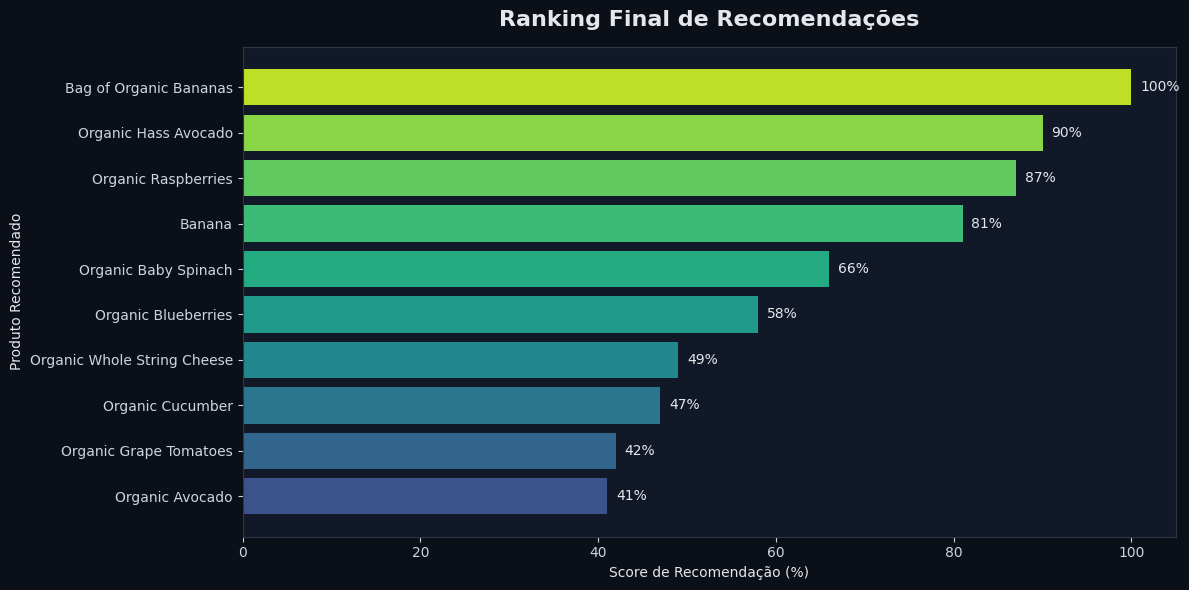

In [24]:
# =========================================
# 📊 RANKING FINAL DAS RECOMENDAÇÕES
# =========================================

import matplotlib.pyplot as plt
import numpy as np

plot_data = hybrid_recommendations.sort_values(
    "recommendation_percent",
    ascending=True
)

colors = plt.cm.viridis(
    np.linspace(0.25, 0.90, len(plot_data))
)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    plot_data["recommended_product"],
    plot_data["recommendation_percent"],
    color=colors
)

plt.title("Ranking Final de Recomendações", fontsize=16)
plt.xlabel("Score de Recomendação (%)")
plt.ylabel("Produto Recomendado")

plt.xlim(0, 105)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.0f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## 📊 **9. Ranking Final das Recomendações**

Nesta etapa, será criado um gráfico horizontal com o ranking final das recomendações geradas pelo modelo híbrido.

A visualização facilita a identificação dos produtos mais relevantes e torna o resultado mais claro para apresentação do projeto.

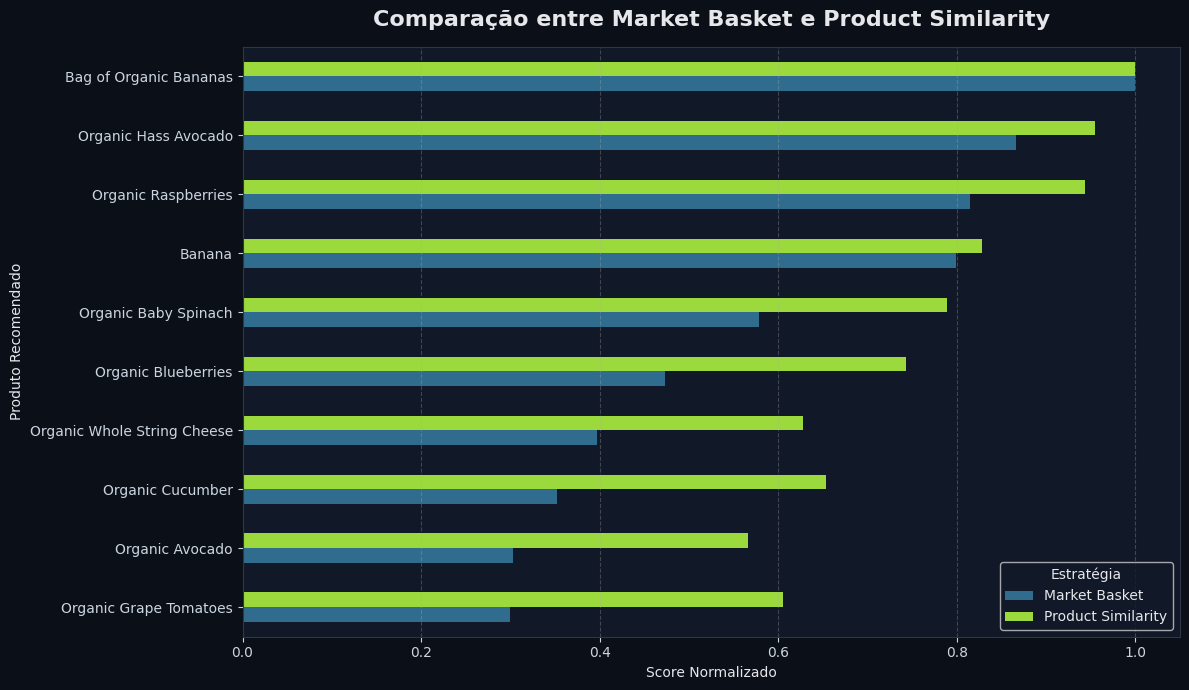

In [25]:
# =========================================
# ⚖️ COMPARAÇÃO DOS SCORES
# =========================================

import matplotlib.pyplot as plt
import numpy as np

comparison_data = hybrid_recommendations[
    [
        "recommended_product",
        "basket_score_norm",
        "similarity_score_norm"
    ]
].copy()

comparison_data = comparison_data.set_index("recommended_product")

comparison_data = comparison_data.sort_values(
    "basket_score_norm",
    ascending=True
)

colors = plt.cm.viridis(
    np.linspace(0.35, 0.85, 2)
)

ax = comparison_data.plot(
    kind="barh",
    figsize=(12, 7),
    color=colors
)

plt.title("Comparação entre Market Basket e Product Similarity", fontsize=16)
plt.xlabel("Score Normalizado")
plt.ylabel("Produto Recomendado")

plt.legend(
    ["Market Basket", "Product Similarity"],
    title="Estratégia"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 🔍 **10. Comparação dos Scores Normalizados**

Nesta etapa, os scores normalizados de Market Basket e Product Similarity serão comparados para cada produto recomendado.

Essa análise ajuda a entender se uma recomendação foi mais influenciada pela coocorrência entre produtos ou pela similaridade de comportamento de compra.

In [27]:
# =========================================
# 📊 COMPARAÇÃO ENTRE ESTRATÉGIAS
# =========================================

test_cart = [
    "Organic Strawberries",
    "Organic Whole Milk"
]

basket_results = recommend_cart_products(
    cart_items=test_cart,
    top_n=10,
    strategy="market_basket"
)

similarity_results = recommend_cart_products(
    cart_items=test_cart,
    top_n=10,
    strategy="similarity"
)

hybrid_results = recommend_cart_products(
    cart_items=test_cart,
    top_n=10,
    strategy="hybrid"
)

basket_results["strategy"] = "Market Basket"
similarity_results["strategy"] = "Product Similarity"
hybrid_results["strategy"] = "Hybrid"

strategy_comparison = pd.concat(
    [
        basket_results,
        similarity_results,
        hybrid_results
    ],
    ignore_index=True
)

strategy_comparison.head()

Produtos no carrinho:
- Organic Strawberries (21137)
- Organic Whole Milk (27845)
Produtos no carrinho:
- Organic Strawberries (21137)
- Organic Whole Milk (27845)
Produtos no carrinho:
- Organic Strawberries (21137)
- Organic Whole Milk (27845)


,recommended_product,recommendation_percent,final_score,basket_score_norm,similarity_score_norm,basket_confidence,basket_lift,basket_cooccurrence,similarity_score,strategy
0,Bag of Organic Bananas,100,1.000000,1.000000,1.000000,0.224272,1.868621,1328,0.185828,Market Basket
1,Organic Hass Avocado,87,0.866212,0.866212,0.954929,0.159223,2.400110,892,0.177453,Market Basket
2,Organic Raspberries,81,0.814669,0.814669,0.943238,0.125971,2.959842,690,0.175280,Market Basket
3,Banana,80,0.798814,0.798814,0.827898,0.231128,1.593325,1337,0.153847,Market Basket
4,Organic Baby Spinach,58,0.578659,0.578659,0.789292,0.137864,1.893737,812,0.146673,Market Basket


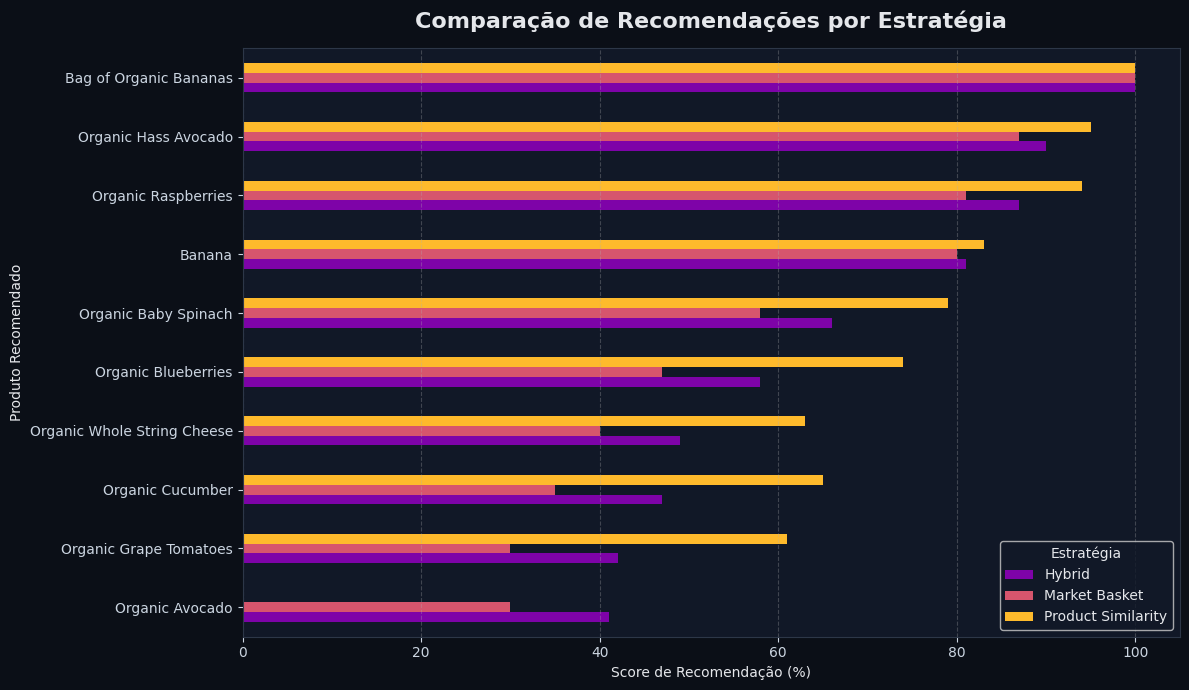

In [28]:
# =========================================
# 📊 TOP RECOMENDAÇÕES POR ESTRATÉGIA
# =========================================

top_strategy_comparison = strategy_comparison[
    strategy_comparison["recommended_product"].isin(
        hybrid_results["recommended_product"].head(10)
    )
]

pivot_comparison = top_strategy_comparison.pivot_table(
    index="recommended_product",
    columns="strategy",
    values="recommendation_percent",
    aggfunc="max",
    fill_value=0
)

pivot_comparison = pivot_comparison.sort_values(
    by="Hybrid",
    ascending=True
)

colors = plt.cm.plasma(
    np.linspace(0.25, 0.85, len(pivot_comparison.columns))
)

ax = pivot_comparison.plot(
    kind="barh",
    figsize=(12, 7),
    color=colors
)

plt.title("Comparação de Recomendações por Estratégia", fontsize=16)
plt.xlabel("Score de Recomendação (%)")
plt.ylabel("Produto Recomendado")

plt.legend(
    title="Estratégia"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 📈 **11. Comparação Consolidada por Estratégia**

Nesta etapa, as recomendações das três estratégias serão reunidas em uma única tabela e visualizadas em conjunto.

O objetivo é observar diferenças de pontuação entre Market Basket, Product Similarity e Hybrid para os principais produtos recomendados.

## 📌 **12. Conclusão**

Neste notebook foi desenvolvido um motor de recomendação híbrido para recomendação **produto → produto**, combinando duas abordagens construídas nas etapas anteriores: **Market Basket Analysis** e **Product Similarity**.

A abordagem de Market Basket contribui com informações sobre produtos frequentemente comprados em conjunto, utilizando métricas como coocorrência, `confidence`, `lift` e `recommendation_score`. Já a abordagem de Product Similarity complementa o sistema ao identificar produtos com padrões de compra semelhantes por meio da similaridade cosseno.

A combinação dessas duas estratégias permite gerar recomendações mais equilibradas, considerando tanto associações diretas entre produtos quanto similaridade de comportamento de compra. Dessa forma, o sistema consegue sugerir itens relevantes a partir dos produtos já presentes no carrinho.

Os testes realizados com produtos como `Organic Strawberries`, `Organic Whole Milk`, `Banana`, `Bag of Organic Bananas` e `Organic Hass Avocado` apresentaram recomendações coerentes, principalmente relacionadas a frutas, vegetais, produtos orgânicos e laticínios. Esse comportamento indica que o modelo híbrido conseguiu capturar padrões reais de consumo presentes na base.

Além disso, foram criadas visualizações para comparar os scores das recomendações e entender a contribuição de cada estratégia no resultado final. Essas análises tornam o sistema mais interpretável e facilitam sua apresentação para usuários técnicos e não técnicos.